# Chapter 3 — Framework 1: Reference-site Ward clustering and finalized-cluster diagnostics

This notebook refactors the reference-only clustering workflow into a clearer analysis narrative while keeping the reusable tools in a dedicated Definition Corner.

The execution structure is:

```text
Inputs → Analysis parameters → Definition Corner → Process → Outputs → Visualization
```

The workflow begins with the A2 reference-site IDs, constructs a selectable site dissimilarity matrix from the stored octave-scale proportional taxa values, fits Ward clustering on that matrix, and then summarizes both the early bifurcation tests and the finalized clusters.

# Inputs

Load the site metadata, the taxa matrix, and the A2 reference-site artifact that identifies the least-polluted sites.

In [38]:
from pathlib import Path
import pandas as pd

STUDY_CASE = "corridor"
SITE_ID_COLUMN = "Integrated Code"

if STUDY_CASE == "DR":
    STUDY_CASE_LABEL = "Detroit River case study"
    CASE_ROOT_DIR = Path("../DetroitRiverCase")
else:
    STUDY_CASE_LABEL = "Corridor case study"
    CASE_ROOT_DIR = Path("..")

METADATA_DIR = CASE_ROOT_DIR / "data"
ARTIFACT_DIR = CASE_ROOT_DIR / "artifacts"
RESULTS_DIR = CASE_ROOT_DIR / "results"
FIGURE_DIR = CASE_ROOT_DIR / "figures"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Load site metadata and taxa composition
site_info = pd.read_excel(METADATA_DIR / "Info.xlsx")
site_ids = site_info[SITE_ID_COLUMN].reset_index(drop=True).rename(SITE_ID_COLUMN)

T = pd.read_excel(METADATA_DIR / "T.xlsx").reset_index(drop=True)
T_with_site_id = pd.concat([site_ids, T], axis=1)

# Load the A2 reference-site artifact
A2 = pd.read_excel(ARTIFACT_DIR / "A2_least_polluted_IDs.xlsx").reset_index(drop=True)

print(f"Study case: {STUDY_CASE_LABEL}")
print(f"Loaded taxa matrix T: {T_with_site_id.shape[0]} sites x {T_with_site_id.shape[1] - 1} taxa variables")
print(f"Loaded A2 reference-site artifact: {A2.shape[0]} sites")
display(T_with_site_id.head())
display(A2.head())

Study case: Corridor case study
Loaded taxa matrix T: 310 sites x 16 taxa variables
Loaded A2 reference-site artifact: 62 sites


,Integrated Code,Oligochaeta,Nematoda,Chironomidae,Ceratopogonidae,Hexagenia,Caenis,Hydropsychidae,Other Trichoptera,Amphipoda,Dreissena,Acari,Hydrozoa,Hirudinea,Turbellaria,Gastropoda,Sphaeriidae
0,DR-02,2.269984,0.563546,1.655598,0.0,0.309116,0.000000,2.438439,0.0,4.529993,6.082918,0.000000,0.00000,0.00000,0.0,0.000000,0.0
1,DR-03,3.808504,3.512091,6.242625,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.801982,0.801982,0.00000,0.00000,0.0,0.456015,0.0
2,DR-04,4.820163,5.519382,4.733464,0.0,0.815949,0.000000,0.000000,0.0,0.000000,0.172158,1.010022,0.00000,0.00000,0.0,0.464907,0.0
3,DR-06,1.449187,0.181596,2.271083,0.0,0.999573,0.033941,0.000000,0.0,1.840242,6.475708,0.000000,1.82093,0.23027,0.0,0.000000,0.0
4,DR-07,1.082238,0.246371,2.499653,0.0,0.128438,0.000000,0.128438,0.0,4.224262,6.266368,0.000000,0.00000,0.00000,0.0,0.246371,0.0


,Integrated Code
0,LSC-26
1,LSC-53
2,LSC-41
3,LSC-42
4,LSC-40


## Analysis parameters

These parameters control the reference subset, the selectable dissimilarity workflow, the finalized Ward partition, the early-bifurcation reporting depth, and the pvclust bootstrap step.

In [39]:
SITE_ID_COLUMN = "Integrated Code"

# T stores proportional taxa after octave transformation.
# Choose how the site dissimilarity matrix is constructed before Ward clustering.
# "cityblock": city-block distance on the stored octave-transformed taxa values
# "hellinger": Euclidean distance on Hellinger-transformed proportions recovered from the stored octave values
# "octave": Euclidean distance on the stored octave-transformed taxa values
DISSIMILARITY_METRIC = "hellinger"

FINAL_K = 2
REPORT_EXTRA_SPLITS = 1
NODEWISE_ALPHA = 0.05
PVCLUST_NBOOT = 1000
CLUSTER_LABEL_COLUMN = "Cluster Label"

M_REFERENCE = int(A2.shape[0])

print("Framework 1 parameter setting")
print("Stored taxa scale: proportional taxa after octave transformation")
print(f"Reference subset size m: {M_REFERENCE}")
print(f"Selected dissimilarity workflow: {DISSIMILARITY_METRIC}")
print(f"Finalized cluster count k: {FINAL_K}")
print(f"Extra reported bifurcations beyond k: {REPORT_EXTRA_SPLITS}")
print(f"Node-wise FDR alpha: {NODEWISE_ALPHA}")
print(f"pvclust bootstrap count: {PVCLUST_NBOOT}")

Framework 1 parameter setting
Stored taxa scale: proportional taxa after octave transformation
Reference subset size m: 62
Selected dissimilarity workflow: hellinger
Finalized cluster count k: 2
Extra reported bifurcations beyond k: 1
Node-wise FDR alpha: 0.05
pvclust bootstrap count: 1000


# Definition Corner

The following cells define the reusable tools used by the visible workflow below. They can be collapsed during reading so that the scientific process remains easy to follow.

In [4]:
from dataclasses import dataclass

import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, to_tree
from scipy.spatial.distance import pdist, squareform


@dataclass
class PVClustResult:
    cluster_results: pd.DataFrame
    node_results: pd.DataFrame


@dataclass
class WardClusteringResult:
    site_ids: list[str]
    distance_matrix: pd.DataFrame
    linkage_matrix: np.ndarray
    node_children: dict[int, tuple[int, int]]
    node_leaves: dict[int, list[int]]
    split_sequence: list[int]
    split_summary: pd.DataFrame
    partitions: dict[int, pd.Series]
    partition_table: pd.DataFrame


@dataclass
class ReferenceClusteringInputs:
    taxa_matrix: pd.DataFrame
    distance_matrix: pd.DataFrame
    dissimilarity_metric: str
    pdist_metric: str
    pvclust_method_dist: str


def select_reference_taxa_subset(
    taxa_matrix: pd.DataFrame,
    reference_ids: pd.DataFrame,
    id_col: str = "Integrated Code",
) -> pd.DataFrame:
    """Subset the taxa matrix to the reference-site IDs stored in A2."""
    if id_col not in taxa_matrix.columns or id_col not in reference_ids.columns:
        raise KeyError(f"Both inputs must contain the identifier column {id_col!r}.")

    taxa_ids = taxa_matrix[id_col].astype(str)
    ordered_ref_ids = reference_ids[id_col].astype(str).reset_index(drop=True)

    if taxa_ids.duplicated().any():
        duplicated_ids = taxa_ids.loc[taxa_ids.duplicated()].unique().tolist()[:5]
        raise ValueError(f"Duplicate site IDs found in the taxa matrix: {duplicated_ids}")

    if ordered_ref_ids.duplicated().any():
        duplicated_ids = ordered_ref_ids.loc[ordered_ref_ids.duplicated()].unique().tolist()[:5]
        raise ValueError(f"Duplicate site IDs found in the reference list: {duplicated_ids}")

    missing_ref_ids = ordered_ref_ids.loc[~ordered_ref_ids.isin(taxa_ids)]
    if not missing_ref_ids.empty:
        preview = missing_ref_ids.tolist()[:10]
        raise ValueError(f"Reference IDs missing from the taxa matrix: {preview}")

    T_ref = taxa_matrix.loc[taxa_ids.isin(ordered_ref_ids)].copy()
    T_ref[id_col] = T_ref[id_col].astype(str)
    T_ref["_ref_order"] = pd.Categorical(
        T_ref[id_col],
        categories=ordered_ref_ids.tolist(),
        ordered=True,
    )
    T_ref = T_ref.sort_values("_ref_order").drop(columns="_ref_order").reset_index(drop=True)
    return T_ref


def _coerce_reference_taxa_numeric(
    T_ref: pd.DataFrame,
    id_col: str = "Integrated Code",
) -> pd.DataFrame:
    """Return the reference taxa matrix as a numeric dataframe indexed by site ID."""
    taxa_columns = [column for column in T_ref.columns if column != id_col]
    if not taxa_columns:
        raise ValueError("T_ref must contain at least one taxa column.")

    taxa_values = T_ref[taxa_columns].apply(pd.to_numeric, errors="coerce")
    if taxa_values.isna().any().any():
        incomplete_columns = taxa_values.columns[taxa_values.isna().any()].tolist()
        raise ValueError(f"Missing or non-numeric taxa values found in: {incomplete_columns}")

    site_index = T_ref[id_col].astype(str)
    taxa_values.index = site_index
    taxa_values.index.name = id_col
    return taxa_values


def recover_proportional_taxa_matrix(
    T_ref: pd.DataFrame,
    id_col: str = "Integrated Code",
    octave_scale: float = 100.0,
    octave_offset: float = 0.01,
) -> pd.DataFrame:
    """Recover proportional taxa values from the stored octave-transformed matrix."""
    octave_taxa = _coerce_reference_taxa_numeric(T_ref, id_col=id_col)
    proportional_taxa = (2.0 ** octave_taxa) / octave_scale - octave_offset
    proportional_taxa = proportional_taxa.clip(lower=0.0)
    proportional_taxa.index.name = id_col
    return proportional_taxa


def hellinger_transform_taxa_matrix(
    T_ref: pd.DataFrame,
    id_col: str = "Integrated Code",
) -> pd.DataFrame:
    """Recover proportional taxa, normalize row totals, and apply the Hellinger transform."""
    proportional_taxa = recover_proportional_taxa_matrix(T_ref, id_col=id_col)
    row_totals = proportional_taxa.sum(axis=1).replace(0.0, np.nan)
    relative_taxa = proportional_taxa.div(row_totals, axis=0).fillna(0.0)
    hellinger_taxa = np.sqrt(relative_taxa)
    hellinger_taxa.index.name = id_col
    return hellinger_taxa


def build_reference_clustering_inputs(
    T_ref: pd.DataFrame,
    dissimilarity_metric: str = "cityblock",
    id_col: str = "Integrated Code",
) -> ReferenceClusteringInputs:
    """Build the taxa matrix and site dissimilarity matrix used by Ward clustering and pvclust."""
    metric_key = str(dissimilarity_metric).strip().lower().replace("-", "_").replace(" ", "_")
    metric_aliases = {
        "cityblock": "cityblock",
        "city_block": "cityblock",
        "manhattan": "cityblock",
        "hellinger": "hellinger",
        "octave": "octave",
    }
    if metric_key not in metric_aliases:
        raise ValueError(
            "Unsupported dissimilarity workflow. Choose one of: 'cityblock', 'hellinger', or 'octave'."
        )

    canonical_metric = metric_aliases[metric_key]
    octave_taxa = _coerce_reference_taxa_numeric(T_ref, id_col=id_col)

    if canonical_metric == "cityblock":
        clustering_taxa = octave_taxa
        pdist_metric = "cityblock"
        pvclust_method_dist = "manhattan"
    elif canonical_metric == "hellinger":
        clustering_taxa = hellinger_transform_taxa_matrix(T_ref, id_col=id_col)
        pdist_metric = "euclidean"
        pvclust_method_dist = "euclidean"
    else:
        clustering_taxa = octave_taxa
        pdist_metric = "euclidean"
        pvclust_method_dist = "euclidean"

    condensed_distance = pdist(clustering_taxa.to_numpy(dtype=float), metric=pdist_metric)
    D_ref = pd.DataFrame(
        squareform(condensed_distance),
        index=clustering_taxa.index,
        columns=clustering_taxa.index,
    )
    D_ref.index.name = id_col
    D_ref.columns.name = id_col

    return ReferenceClusteringInputs(
        taxa_matrix=clustering_taxa,
        distance_matrix=D_ref,
        dissimilarity_metric=canonical_metric,
        pdist_metric=pdist_metric,
        pvclust_method_dist=pvclust_method_dist,
    )


def build_cityblock_dissimilarity(
    T_ref: pd.DataFrame,
    id_col: str = "Integrated Code",
) -> pd.DataFrame:
    """Backward-compatible wrapper for the city-block workflow."""
    return build_reference_clustering_inputs(
        T_ref,
        dissimilarity_metric="cityblock",
        id_col=id_col,
    ).distance_matrix


def _collect_tree_maps(node, node_children: dict[int, tuple[int, int]], node_leaves: dict[int, list[int]]) -> None:
    if node.is_leaf():
        node_leaves[node.id] = [node.id]
        return

    _collect_tree_maps(node.left, node_children, node_leaves)
    _collect_tree_maps(node.right, node_children, node_leaves)
    node_children[node.id] = (node.left.id, node.right.id)
    node_leaves[node.id] = node_leaves[node.left.id] + node_leaves[node.right.id]


def _labels_from_active_nodes(
    active_nodes: list[int],
    node_leaves: dict[int, list[int]],
    site_ids: list[str],
) -> pd.Series:
    ordered_nodes = sorted(active_nodes, key=lambda node_id: min(node_leaves[node_id]))
    labels = np.zeros(len(site_ids), dtype=int)
    for label, node_id in enumerate(ordered_nodes, start=1):
        labels[node_leaves[node_id]] = label
    return pd.Series(labels, index=site_ids, name=f"k_{len(ordered_nodes)}")


def perform_ward_clustering(D_ref: pd.DataFrame) -> WardClusteringResult:
    """Fit Ward clustering to the precomputed site dissimilarity matrix."""
    site_ids = D_ref.index.astype(str).tolist()
    condensed_distance = squareform(D_ref.to_numpy(dtype=float), checks=False)
    linkage_matrix = linkage(condensed_distance, method="ward")
    root, _ = to_tree(linkage_matrix, rd=True)

    node_children: dict[int, tuple[int, int]] = {}
    node_leaves: dict[int, list[int]] = {}
    _collect_tree_maps(root, node_children, node_leaves)

    n_sites = len(site_ids)
    active_nodes = [root.id]
    partitions = {
        1: pd.Series(np.ones(n_sites, dtype=int), index=site_ids, name="k_1")
    }
    split_sequence: list[int] = []
    split_records: list[dict[str, float | int]] = []

    for target_k in range(2, n_sites + 1):
        splittable_nodes = [node_id for node_id in active_nodes if node_id >= n_sites]
        if not splittable_nodes:
            break

        node_id = max(
            splittable_nodes,
            key=lambda candidate_id: linkage_matrix[candidate_id - n_sites, 2],
        )
        active_nodes.remove(node_id)
        left_id, right_id = node_children[node_id]
        active_nodes.extend([left_id, right_id])
        split_sequence.append(node_id)

        split_records.append(
            {
                "split_id": len(split_sequence),
                "node_id": node_id,
                "left_node_id": left_id,
                "right_node_id": right_id,
                "linkage": float(linkage_matrix[node_id - n_sites, 2]),
                "n_left": len(node_leaves[left_id]),
                "n_right": len(node_leaves[right_id]),
            }
        )
        partitions[target_k] = _labels_from_active_nodes(active_nodes, node_leaves, site_ids)

    partition_table = pd.DataFrame({f"k_{k}": partition for k, partition in partitions.items()})
    partition_table.index.name = D_ref.index.name or "Integrated Code"
    split_summary = pd.DataFrame(split_records)

    return WardClusteringResult(
        site_ids=site_ids,
        distance_matrix=D_ref.copy(),
        linkage_matrix=linkage_matrix,
        node_children=node_children,
        node_leaves=node_leaves,
        split_sequence=split_sequence,
        split_summary=split_summary,
        partitions=partitions,
        partition_table=partition_table,
    )


def materialize_final_cluster_label_table(
    ward_result: WardClusteringResult,
    final_k: int,
    site_id_column: str = "Integrated Code",
    cluster_column: str = "Cluster Label",
    cluster_prefix: str = "C",
) -> pd.DataFrame:
    """Return one row per reference site with its finalized Ward cluster label."""
    if final_k not in ward_result.partitions:
        raise ValueError(f"No partition available for k = {final_k}.")

    final_partition = ward_result.partitions[final_k].loc[ward_result.site_ids]
    cluster_label_table = pd.DataFrame(
        {
            site_id_column: final_partition.index.astype(str),
            cluster_column: [f"{cluster_prefix}{int(cluster_id)}" for cluster_id in final_partition.to_numpy()],
        }
    )
    return cluster_label_table.reset_index(drop=True)

In [5]:
import warnings

from scipy.stats import ConstantInputWarning, f as f_distribution, f_oneway
from statsmodels.stats.multitest import multipletests


def _safe_oneway_anova(left_values: np.ndarray, right_values: np.ndarray) -> tuple[float, float]:
    left_values = np.asarray(left_values, dtype=float)
    right_values = np.asarray(right_values, dtype=float)

    if left_values.size < 2 or right_values.size < 2:
        return np.nan, np.nan

    if (
        np.allclose(left_values, left_values[0])
        and np.allclose(right_values, right_values[0])
        and np.isclose(left_values[0], right_values[0])
    ):
        return 0.0, 1.0

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConstantInputWarning)
        warnings.simplefilter("ignore", category=RuntimeWarning)
        f_statistic, p_value = f_oneway(left_values, right_values)

    if np.isnan(f_statistic) or np.isnan(p_value):
        if (
            np.allclose(left_values, left_values[0])
            and np.allclose(right_values, right_values[0])
            and not np.isclose(left_values[0], right_values[0])
        ):
            return np.inf, 0.0
        return np.nan, np.nan

    return float(f_statistic), float(p_value)


def fit_nodewise_anova(
    T_ref: pd.DataFrame,
    ward_result: WardClusteringResult,
    id_col: str = "Integrated Code",
) -> pd.DataFrame:
    """Fit one-way ANOVA models for each taxon at each top-down bifurcation node."""
    taxa_columns = [column for column in T_ref.columns if column != id_col]
    aligned_taxa = T_ref.set_index(id_col).loc[ward_result.site_ids, taxa_columns]

    records: list[dict[str, float | int | str]] = []
    for split_row in ward_result.split_summary.itertuples(index=False):
        left_leaf_indices = ward_result.node_leaves[split_row.left_node_id]
        right_leaf_indices = ward_result.node_leaves[split_row.right_node_id]
        left_site_ids = [ward_result.site_ids[index] for index in left_leaf_indices]
        right_site_ids = [ward_result.site_ids[index] for index in right_leaf_indices]

        split_records: list[dict[str, float | int | str]] = []
        raw_p_values: list[float] = []

        for taxon in taxa_columns:
            left_values = aligned_taxa.loc[left_site_ids, taxon].to_numpy(dtype=float)
            right_values = aligned_taxa.loc[right_site_ids, taxon].to_numpy(dtype=float)
            f_statistic, p_value = _safe_oneway_anova(left_values, right_values)

            split_records.append(
                {
                    "split_id": split_row.split_id,
                    "n_left": split_row.n_left,
                    "n_right": split_row.n_right,
                    "taxon": taxon,
                    "xbar_left": float(np.nanmean(left_values)),
                    "xbar_right": float(np.nanmean(right_values)),
                    "F": f_statistic,
                    "p": p_value,
                }
            )
            raw_p_values.append(p_value)

        adjusted_p_values = np.full(len(raw_p_values), np.nan, dtype=float)
        raw_p_values = np.asarray(raw_p_values, dtype=float)
        valid_mask = ~np.isnan(raw_p_values)
        if valid_mask.any():
            _, adjusted_valid, _, _ = multipletests(raw_p_values[valid_mask], method="fdr_bh")
            adjusted_p_values[valid_mask] = adjusted_valid

        for split_record, adjusted_p_value in zip(split_records, adjusted_p_values):
            split_record["p_FDR"] = float(adjusted_p_value) if np.isfinite(adjusted_p_value) else np.nan
            records.append(split_record)

    return pd.DataFrame(records)


def summarize_nodewise_anova(
    anova_results: pd.DataFrame,
    n_splits: int,
    alpha: float = 0.05,
) -> pd.DataFrame:
    """Return significant per-taxon ANOVA rows for the first n_splits bifurcation nodes."""
    columns = [
        "split_id",
        "n_left",
        "n_right",
        "taxon",
        "xbar_left",
        "xbar_right",
        "F",
        "p",
        "p_FDR",
    ]
    summary = anova_results.loc[
        (anova_results["split_id"] <= n_splits) & (anova_results["p_FDR"] <= alpha),
        columns,
    ].copy()
    return summary.sort_values(["split_id", "p_FDR", "p", "F"], ascending=[True, True, True, False]).reset_index(drop=True)


def _multi_group_anova(values_by_cluster: list[np.ndarray]) -> tuple[float, float, float, float]:
    clean_groups = [np.asarray(values, dtype=float)[~np.isnan(values)] for values in values_by_cluster]
    if len(clean_groups) < 2 or any(group.size == 0 for group in clean_groups):
        return np.nan, np.nan, np.nan, np.nan

    all_values = np.concatenate(clean_groups)
    df_between = len(clean_groups) - 1
    df_within = all_values.size - len(clean_groups)
    if df_between <= 0 or df_within <= 0:
        return np.nan, np.nan, np.nan, np.nan

    overall_mean = float(np.mean(all_values))
    group_means = [float(np.mean(group)) for group in clean_groups]
    ss_between = float(sum(group.size * (group_mean - overall_mean) ** 2 for group, group_mean in zip(clean_groups, group_means)))
    ss_within = float(sum(np.sum((group - group_mean) ** 2) for group, group_mean in zip(clean_groups, group_means)))

    if np.isclose(ss_between, 0.0) and np.isclose(ss_within, 0.0):
        return 0.0, 0.0, 0.0, 1.0
    if np.isclose(ss_within, 0.0):
        return ss_between, ss_within, np.inf, 0.0

    f_statistic = (ss_between / df_between) / (ss_within / df_within)
    p_value = float(f_distribution.sf(f_statistic, df_between, df_within))
    return ss_between, ss_within, float(f_statistic), p_value


def _format_mean_se(values: np.ndarray) -> str:
    clean_values = np.asarray(values, dtype=float)[~np.isnan(values)]
    if clean_values.size == 0:
        return ""
    mean_value = float(np.mean(clean_values))
    if clean_values.size == 1:
        error_value = 0.0
    else:
        error_value = float(np.std(clean_values, ddof=1) / np.sqrt(clean_values.size))
    return f"{mean_value:.2f} ± {error_value:.2f}"


def _format_p_value(p_value: float) -> str:
    if np.isnan(p_value):
        return ""
    if p_value < 0.001:
        stars = "***"
    elif p_value < 0.01:
        stars = "**"
    elif p_value < 0.05:
        stars = "*"
    else:
        stars = ""
    return f"{p_value:.4f}{stars}"


def summarize_finalized_cluster_anova(
    T_ref: pd.DataFrame,
    ward_result: WardClusteringResult,
    final_k: int,
    id_col: str = "Integrated Code",
) -> pd.DataFrame:
    """Summarize one-way ANOVA across the finalized K clusters for each taxon."""
    if final_k not in ward_result.partitions:
        raise ValueError(f"No partition available for k = {final_k}.")

    taxa_columns = [column for column in T_ref.columns if column != id_col]
    aligned_taxa = T_ref.set_index(id_col).loc[ward_result.site_ids, taxa_columns]
    final_clusters = ward_result.partitions[final_k].loc[ward_result.site_ids]
    cluster_ids = sorted(pd.unique(final_clusters))

    ss_between_col = f"SS Between\n(df = {final_k - 1})"
    ss_within_col = f"SS Within\n(df = {len(final_clusters) - final_k})"
    cluster_columns = [f"Cluster\nC{cluster_id}" for cluster_id in cluster_ids]

    records: list[dict[str, object]] = []
    for taxon in taxa_columns:
        values_by_cluster = [
            aligned_taxa.loc[final_clusters[final_clusters == cluster_id].index, taxon].to_numpy(dtype=float)
            for cluster_id in cluster_ids
        ]
        ss_between, ss_within, f_statistic, p_value = _multi_group_anova(values_by_cluster)

        row: dict[str, object] = {
            "Taxon": taxon,
            ss_between_col: ss_between,
            ss_within_col: ss_within,
            "F": f_statistic,
            "p": _format_p_value(p_value),
            "_p_value": p_value,
        }
        for cluster_values, cluster_column in zip(values_by_cluster, cluster_columns):
            row[cluster_column] = _format_mean_se(cluster_values)
        records.append(row)

    summary = pd.DataFrame(records).sort_values(["_p_value", "F"], ascending=[True, False], na_position="last").reset_index(drop=True)
    for numeric_column in [ss_between_col, ss_within_col, "F"]:
        summary[numeric_column] = summary[numeric_column].map(lambda value: "" if pd.isna(value) else f"{value:.2f}")
    summary = summary.drop(columns="_p_value")

    size_row = {
        "Taxon": "Sample size (n)",
        ss_between_col: "",
        ss_within_col: "",
        "F": "",
        "p": "",
    }
    for cluster_id, cluster_column in zip(cluster_ids, cluster_columns):
        size_row[cluster_column] = int((final_clusters == cluster_id).sum())

    return pd.concat([summary, pd.DataFrame([size_row])], ignore_index=True)

In [6]:
import shutil
import subprocess
import tempfile
from pathlib import Path


def _parse_member_string(member_string: str) -> frozenset[str]:
    member_parts = [member for member in str(member_string).split("|") if member]
    return frozenset(member_parts)


def extract_pvclust_au_pvalues(
    T_ref: pd.DataFrame,
    ward_result: WardClusteringResult,
    final_k: int,
    id_col: str = "Integrated Code",
    nboot: int = 200,
    method_dist: str = "manhattan",
    method_hclust: str = "ward.D2",
    clustering_taxa_matrix: pd.DataFrame | None = None,
) -> PVClustResult:
    """Run pvclust on the taxa matrix aligned with the selected dissimilarity workflow."""
    if final_k not in ward_result.partitions:
        raise ValueError(f"No partition available for k = {final_k}.")

    rscript_path = shutil.which("Rscript")
    if rscript_path is None:
        raise EnvironmentError("Rscript is not available on PATH.")

    if clustering_taxa_matrix is None:
        taxa_columns = [column for column in T_ref.columns if column != id_col]
        aligned_taxa = T_ref.set_index(id_col).loc[ward_result.site_ids, taxa_columns]
        pvclust_input = aligned_taxa.apply(pd.to_numeric, errors="raise").T
    else:
        aligned_taxa = clustering_taxa_matrix.loc[ward_result.site_ids]
        pvclust_input = aligned_taxa.apply(pd.to_numeric, errors="raise").T

    with tempfile.TemporaryDirectory() as tmp_dir_name:
        tmp_dir = Path(tmp_dir_name)
        input_path = tmp_dir / "pvclust_input.csv"
        output_path = tmp_dir / "pvclust_nodes.csv"
        script_path = tmp_dir / "extract_pvclust_nodes.R"

        pvclust_input.to_csv(input_path)
        script_path.write_text(
            "\n".join([
                "args <- commandArgs(trailingOnly = TRUE)",
                "input_path <- args[1]",
                "output_path <- args[2]",
                "nboot <- as.integer(args[3])",
                "method_dist <- args[4]",
                "method_hclust <- args[5]",
                "suppressPackageStartupMessages(library(pvclust))",
                "data_mat <- as.matrix(read.csv(input_path, row.names = 1, check.names = FALSE))",
                "fit <- pvclust(data_mat, method.hclust = method_hclust, method.dist = method_dist, nboot = nboot, parallel = FALSE)",
                "merge_mat <- fit$hclust$merge",
                "labels <- fit$hclust$labels",
                "get_members <- function(node_id) {",
                "  if (node_id < 0) return(labels[-node_id])",
                "  child_nodes <- merge_mat[node_id, ]",
                "  c(get_members(child_nodes[1]), get_members(child_nodes[2]))",
                "}",
                "member_strings <- vapply(seq_len(nrow(merge_mat)), function(i) paste(sort(get_members(i)), collapse = '|'), character(1))",
                "out <- data.frame(node_id = seq_len(nrow(merge_mat)), au = fit$edges[, 'au'], bp = fit$edges[, 'bp'], members = member_strings, stringsAsFactors = FALSE)",
                "write.csv(out, output_path, row.names = FALSE)",
            ]),
            encoding="utf-8",
        )

        completed_process = subprocess.run(
            [
                rscript_path,
                str(script_path),
                str(input_path),
                str(output_path),
                str(int(nboot)),
                method_dist,
                method_hclust,
            ],
            check=False,
            capture_output=True,
            text=True,
        )
        if completed_process.returncode != 0:
            error_message = completed_process.stderr.strip() or completed_process.stdout.strip() or "pvclust execution failed."
            raise RuntimeError(error_message)

        node_results = pd.read_csv(output_path)

    node_results["members_set"] = node_results["members"].map(_parse_member_string)
    finalized_clusters = ward_result.partitions[final_k].loc[ward_result.site_ids]

    cluster_records: list[dict[str, object]] = []
    for cluster_id in sorted(pd.unique(finalized_clusters)):
        cluster_members = frozenset(finalized_clusters[finalized_clusters == cluster_id].index.astype(str))
        candidate_rows: list[tuple[bool, float, int, int, pd.Series]] = []
        for _, node_row in node_results.iterrows():
            node_members = node_row["members_set"]
            intersection_size = len(cluster_members & node_members)
            union_size = len(cluster_members | node_members)
            jaccard = intersection_size / union_size if union_size else 0.0
            exact_match = node_members == cluster_members
            size_gap = abs(len(node_members) - len(cluster_members))
            candidate_rows.append((exact_match, jaccard, intersection_size, -size_gap, node_row))

        best_exact, best_jaccard, _, _, best_row = max(
            candidate_rows,
            key=lambda item: (item[0], item[1], item[2], item[3]),
        )
        cluster_records.append(
            {
                "Cluster": f"C{cluster_id}",
                "n": len(cluster_members),
                "AU": float(best_row["au"]),
                "BP": float(best_row["bp"]),
                "Match": "exact" if best_exact else "nearest",
                "Jaccard": float(best_jaccard),
                "Members": ", ".join(sorted(cluster_members)),
            }
        )

    cluster_results = pd.DataFrame(cluster_records).sort_values("Cluster").reset_index(drop=True)
    node_results = node_results.drop(columns="members_set")
    return PVClustResult(cluster_results=cluster_results, node_results=node_results)

In [26]:
import re

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import dendrogram, set_link_color_palette


DEFAULT_CLUSTER_PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
DEFAULT_TAXON_ORDER = [
    "Oligochaeta",
    "Chironomidae",
    "Nematoda",
    "Sphaeriidae",
    "Acari",
    "Hexagenia",
    "Caenis",
    "Hirudinea",
    "Turbellaria",
    "Gastropoda",
    "Hydrozoa",
    "Other Trichoptera",
    "Amphipoda",
    "Hydropsychidae",
    "Dreissena",
    "Ceratopogonidae",
]


def _parse_cluster_id(label: str) -> int:
    match = re.search(r"C(\d+)", str(label))
    if match is None:
        raise ValueError(f"Could not parse cluster id from label: {label}")
    return int(match.group(1))


def compute_cut_height(split_summary: pd.DataFrame, final_k: int) -> float | None:
    if final_k < 1:
        raise ValueError("final_k must be at least 1.")
    if split_summary.empty:
        return None
    if final_k == 1:
        return float(split_summary.loc[0, "linkage"] + 1e-6)
    if final_k > len(split_summary) + 1:
        raise ValueError("final_k cannot exceed the number of reference sites.")

    upper_height = float(split_summary.loc[final_k - 2, "linkage"])
    if final_k - 1 < len(split_summary):
        lower_height = float(split_summary.loc[final_k - 1, "linkage"])
        return (upper_height + lower_height) / 2.0
    return upper_height / 2.0


def _build_cluster_color_map(
    ward_result: WardClusteringResult,
    final_k: int,
    palette: list[str] | None = None,
) -> dict[int, str]:
    if final_k not in ward_result.partitions:
        raise ValueError(f"No partition available for k = {final_k}.")

    palette = palette or DEFAULT_CLUSTER_PALETTE
    cut_height = compute_cut_height(ward_result.split_summary, final_k)
    color_threshold = cut_height if cut_height is not None and cut_height > 0 else None

    set_link_color_palette(palette)
    dendrogram_data = dendrogram(
        ward_result.linkage_matrix,
        labels=ward_result.site_ids,
        orientation="left",
        color_threshold=color_threshold,
        above_threshold_color="#8a8a8a",
        no_plot=True,
    )
    set_link_color_palette(None)

    leaf_labels = dendrogram_data.get("ivl", [])
    leaf_colors = dendrogram_data.get("leaves_color_list", [])
    leaf_color_map = dict(zip(leaf_labels, leaf_colors))

    final_clusters = ward_result.partitions[final_k].loc[ward_result.site_ids]
    cluster_color_map: dict[int, str] = {}
    for cluster_id in sorted(pd.unique(final_clusters)):
        cluster_members = final_clusters[final_clusters == cluster_id].index.astype(str)
        member_colors = [leaf_color_map.get(member) for member in cluster_members]
        member_colors = [color for color in member_colors if color and color != "#8a8a8a"]
        if member_colors:
            color = max(set(member_colors), key=member_colors.count)
        else:
            color = palette[(int(cluster_id) - 1) % len(palette)]
        cluster_color_map[int(cluster_id)] = color

    return cluster_color_map


def _parse_mean_se(value: object) -> tuple[float, float]:
    text = str(value).strip()
    if not text or text.lower() == "nan":
        return np.nan, np.nan
    if "±" not in text:
        return float(text), 0.0
    mean_text, se_text = [part.strip() for part in text.split("±", maxsplit=1)]
    return float(mean_text), float(se_text)


def _extract_significance_stars(value: object) -> str:
    match = re.search(r"(\*+)$", str(value).strip())
    return match.group(1) if match else ""


def _invert_octave_to_proportion(value: float, octave_scale: float = 100.0, octave_offset: float = 0.01) -> float:
    if np.isnan(value):
        return np.nan
    return max((2.0 ** float(value)) / octave_scale - octave_offset, 0.0)

def _invert_hellinger_to_proportion(value: float) -> float:
    if np.isnan(value):
        return np.nan
    return max(float(value) ** 2, 0.0)


def render_finalized_cluster_barplot(
    finalized_cluster_anova_table: pd.DataFrame,
    ward_result: WardClusteringResult,
    final_k: int,
    taxon_order: list[str] | None = None,
    cluster_color_map: dict[int, str] | None = None,
    figsize: tuple[float, float] = (16, 7),
    dpi: int = 300,
) -> tuple[plt.Figure, plt.Axes]:
    """Visualize finalized-cluster means in proportion space with upper-only SE bars."""
    taxon_order = taxon_order or DEFAULT_TAXON_ORDER
    cluster_color_map = cluster_color_map or _build_cluster_color_map(ward_result, final_k)

    plot_table = finalized_cluster_anova_table.loc[
        finalized_cluster_anova_table["Taxon"] != "Sample size (n)",
    ].copy()
    plot_table = plot_table.set_index("Taxon")

    ordered_taxa = [taxon for taxon in taxon_order if taxon in plot_table.index]
    remaining_taxa = [taxon for taxon in plot_table.index if taxon not in ordered_taxa]
    ordered_taxa.extend(remaining_taxa)
    plot_table = plot_table.loc[ordered_taxa].reset_index()

    cluster_columns = [column for column in plot_table.columns if str(column).startswith("Cluster")]
    cluster_columns = sorted(cluster_columns, key=_parse_cluster_id)
    cluster_ids = [_parse_cluster_id(column) for column in cluster_columns]

    x_positions = np.arange(len(plot_table))
    bar_width = 0.8 / max(len(cluster_columns), 1)
    offsets = np.linspace(-0.4 + bar_width / 2.0, 0.4 - bar_width / 2.0, len(cluster_columns))

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    overall_max = 0.0
    legend_handles: list[Patch] = []
    for offset, cluster_id, cluster_column in zip(offsets, cluster_ids, cluster_columns):
        mean_values = []
        upper_error_values = []
        for value in plot_table[cluster_column]:
            mean_value, error_value = _parse_mean_se(value)
            mean_proportion = _invert_hellinger_to_proportion(mean_value)
            upper_proportion = _invert_hellinger_to_proportion(mean_value + error_value)
            mean_values.append(mean_proportion)
            upper_error_values.append(max(upper_proportion - mean_proportion, 0.0))
        mean_values_array = np.asarray(mean_values, dtype=float)
        upper_error_array = np.asarray(upper_error_values, dtype=float)
        overall_max = max(overall_max, float(np.nanmax(mean_values_array + upper_error_array)))

        color = cluster_color_map.get(cluster_id, DEFAULT_CLUSTER_PALETTE[(cluster_id - 1) % len(DEFAULT_CLUSTER_PALETTE)])
        ax.bar(
            x_positions + offset,
            mean_values_array,
            width=bar_width,
            yerr=np.vstack([np.zeros_like(upper_error_array), upper_error_array]),
            color=color,
            edgecolor="black",
            linewidth=0.3,
            error_kw={"elinewidth": 1.0, "capsize": 2},
            label=f"Cluster {cluster_id}",
        )
        legend_handles.append(Patch(facecolor=color, edgecolor="black", label=f"Cluster {cluster_id}"))

    y_offset = 0.03 * overall_max if overall_max > 0 else 0.02
    for x_position, (_, row) in zip(x_positions, plot_table.iterrows()):
        stars = _extract_significance_stars(row["p"] if "p" in row else "")
        if not stars:
            continue
        taxon_peak = 0.0
        for cluster_column in cluster_columns:
            mean_value, error_value = _parse_mean_se(row[cluster_column])
            mean_proportion = _invert_hellinger_to_proportion(mean_value)
            upper_proportion = _invert_hellinger_to_proportion(mean_value + error_value)
            taxon_peak = max(taxon_peak, upper_proportion, mean_proportion)
        ax.text(
            x_position,
            taxon_peak + y_offset,
            stars,
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )

    y_tick_values = np.array([0.0, 0.02, 0.04, 0.08, 0.16, 0.32, 0.40], dtype=float)
    y_tick_labels = ["0%", "2%", "4%", "8%", "16%", "32%", "40%"]
    y_limit_upper = max(overall_max + 4 * y_offset, float(y_tick_values[-1]))

    ax.set_xticks(x_positions)
    ax.set_xticklabels(plot_table["Taxon"], rotation=35, ha="right", fontsize=10)
    ax.set_yticks(y_tick_values)
    ax.set_yticklabels(y_tick_labels)
    ax.set_ylabel("Mean Relative Abundance (+SE)", fontsize=13, fontweight="bold")
    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.set_ylim(0, y_limit_upper)
    ax.legend(handles=legend_handles, loc="upper right", frameon=True, fontsize=10)
    fig.tight_layout()
    return fig, ax


def render_cluster_dendrogram(
    ward_result: WardClusteringResult,
    final_k: int | None = None,
    pvclust_result: PVClustResult | None = None,
    figure_path: Path | None = None,
    figsize: tuple[float, float] | None = None,
    dpi: int = 300,
) -> tuple[plt.Figure, plt.Axes]:
    """Draw a horizontal Ward dendrogram with linkage distance on x and site labels on the right."""
    cut_height = None
    color_threshold = None
    cluster_color_map: dict[int, str] = {}
    if final_k is not None:
        cut_height = compute_cut_height(ward_result.split_summary, final_k)
        if cut_height is not None and cut_height > 0:
            color_threshold = cut_height
        cluster_color_map = _build_cluster_color_map(ward_result, final_k)

    n_sites = len(ward_result.site_ids)
    if figsize is None:
        figsize = (10.0, max(8.0, 0.18 * n_sites))

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    set_link_color_palette(DEFAULT_CLUSTER_PALETTE)
    dendrogram(
        ward_result.linkage_matrix,
        labels=ward_result.site_ids,
        orientation="left",
        leaf_rotation=0,
        leaf_font_size=9,
        color_threshold=color_threshold,
        above_threshold_color="#8a8a8a",
        ax=ax,
    )
    set_link_color_palette(None)

    for collection in ax.collections:
        collection.set_linewidth(1.6)

    ax.grid(axis="x", color="#d9d9d9", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=9, length=0)
    ax.set_xlabel("Linkage Distance", fontsize=12)
    ax.set_ylabel(f"{n_sites} Least-polluted Sites", fontsize=12)
    title = f"Ward Dendrogram -- {n_sites} Least-polluted Sites"
    if final_k is not None:
        title = f"{title} (k = {final_k})"
    ax.set_title(title, fontsize=17, fontweight="bold")

    if pvclust_result is not None and final_k is not None:
        legend_handles: list[Patch] = []
        for row in pvclust_result.cluster_results.sort_values("Cluster").itertuples(index=False):
            cluster_id = _parse_cluster_id(row.Cluster)
            color = cluster_color_map.get(cluster_id, DEFAULT_CLUSTER_PALETTE[(cluster_id - 1) % len(DEFAULT_CLUSTER_PALETTE)])
            legend_handles.append(
                Patch(
                    facecolor=color,
                    edgecolor="black",
                    label=fr"AU of $C_{{{cluster_id}}}$ = {row.AU:.4f}",
                )
            )
        ax.legend(handles=legend_handles, loc="upper left", frameon=True, fontsize=10)

    fig.tight_layout()

    if figure_path is not None:
        figure_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(figure_path, dpi=dpi, bbox_inches="tight")

    return fig, ax

In [35]:
# Override the finalized-cluster barplot so doubling percentage ticks have equal visual gaps.

def _equal_gap_relative_scale(value: float, first_gap: float = 0.02) -> float:

    if np.isnan(value) or value <= 0:

        return 0.0

    if first_gap <= 0:

        raise ValueError("first_gap must be positive.")

    if value <= first_gap:

        return float(value / first_gap)

    return float(1.0 + np.log2(value / first_gap))





def _build_equal_gap_ticks(max_value: float, first_gap: float = 0.02) -> tuple[np.ndarray, list[str], np.ndarray]:

    tick_values = [0.0]

    tick_labels = ["0%"]

    tick_positions = [0.0]

    current_value = first_gap

    upper_bound = max(float(max_value), first_gap)



    while current_value < upper_bound:

        tick_values.append(current_value)

        tick_labels.append(f"{current_value * 100:.0f}%")

        tick_positions.append(_equal_gap_relative_scale(current_value, first_gap=first_gap))

        current_value *= 2.0



    if tick_values[-1] < upper_bound:

        tick_values.append(current_value)

        tick_labels.append(f"{current_value * 100:.0f}%")

        tick_positions.append(_equal_gap_relative_scale(current_value, first_gap=first_gap))



    return np.asarray(tick_values, dtype=float), tick_labels, np.asarray(tick_positions, dtype=float)





def render_finalized_cluster_barplot(

    finalized_cluster_anova_table: pd.DataFrame,

    ward_result: WardClusteringResult,

    final_k: int,

    taxon_order: list[str] | None = None,

    cluster_color_map: dict[int, str] | None = None,

    figsize: tuple[float, float] = (16, 7),

    dpi: int = 300,

) -> tuple[plt.Figure, plt.Axes]:

    """Visualize finalized-cluster means in proportion space with upper-only SE bars."""

    taxon_order = taxon_order or DEFAULT_TAXON_ORDER

    cluster_color_map = cluster_color_map or _build_cluster_color_map(ward_result, final_k)



    plot_table = finalized_cluster_anova_table.loc[

        finalized_cluster_anova_table["Taxon"] != "Sample size (n)",

    ].copy()

    plot_table = plot_table.set_index("Taxon")



    ordered_taxa = [taxon for taxon in taxon_order if taxon in plot_table.index]

    remaining_taxa = [taxon for taxon in plot_table.index if taxon not in ordered_taxa]

    ordered_taxa.extend(remaining_taxa)

    plot_table = plot_table.loc[ordered_taxa].reset_index()



    cluster_columns = [column for column in plot_table.columns if str(column).startswith("Cluster")]

    cluster_columns = sorted(cluster_columns, key=_parse_cluster_id)

    cluster_ids = [_parse_cluster_id(column) for column in cluster_columns]



    x_positions = np.arange(len(plot_table))

    bar_width = 0.8 / max(len(cluster_columns), 1)

    offsets = np.linspace(-0.4 + bar_width / 2.0, 0.4 - bar_width / 2.0, len(cluster_columns))



    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    fig.patch.set_facecolor("white")

    ax.set_facecolor("white")



    overall_max = 0.0

    display_max = 0.0

    legend_handles: list[Patch] = []

    for offset, cluster_id, cluster_column in zip(offsets, cluster_ids, cluster_columns):

        mean_values = []

        upper_error_values = []

        for value in plot_table[cluster_column]:

            mean_value, error_value = _parse_mean_se(value)

            mean_proportion = _invert_hellinger_to_proportion(mean_value)

            upper_proportion = _invert_hellinger_to_proportion(mean_value + error_value)

            mean_position = _equal_gap_relative_scale(mean_proportion)

            upper_position = _equal_gap_relative_scale(upper_proportion)

            mean_values.append(mean_position)

            upper_error_values.append(max(upper_position - mean_position, 0.0))

            overall_max = max(overall_max, upper_proportion, mean_proportion)

        mean_values_array = np.asarray(mean_values, dtype=float)

        upper_error_array = np.asarray(upper_error_values, dtype=float)

        display_max = max(display_max, float(np.nanmax(mean_values_array + upper_error_array)))



        color = cluster_color_map.get(cluster_id, DEFAULT_CLUSTER_PALETTE[(cluster_id - 1) % len(DEFAULT_CLUSTER_PALETTE)])

        ax.bar(

            x_positions + offset,

            mean_values_array,

            width=bar_width,

            yerr=np.vstack([np.zeros_like(upper_error_array), upper_error_array]),

            color=color,

            edgecolor="black",

            linewidth=0.3,

            error_kw={"elinewidth": 1.0, "capsize": 2},

            label=f"Cluster {cluster_id}",

        )

        legend_handles.append(Patch(facecolor=color, edgecolor="black", label=f"Cluster {cluster_id}"))



    y_offset = 0.03 * display_max if display_max > 0 else 0.02

    for x_position, (_, row) in zip(x_positions, plot_table.iterrows()):

        stars = _extract_significance_stars(row["p"] if "p" in row else "")

        if not stars:

            continue

        taxon_peak = 0.0

        for cluster_column in cluster_columns:

            mean_value, error_value = _parse_mean_se(row[cluster_column])

            mean_proportion = _invert_hellinger_to_proportion(mean_value)

            upper_proportion = _invert_hellinger_to_proportion(mean_value + error_value)

            taxon_peak = max(

                taxon_peak,

                _equal_gap_relative_scale(upper_proportion),

                _equal_gap_relative_scale(mean_proportion),

            )

        ax.text(

            x_position,

            taxon_peak + y_offset,

            stars,

            ha="center",

            va="bottom",

            fontsize=11,

            fontweight="bold",

        )



    _, y_tick_labels, y_tick_positions = _build_equal_gap_ticks(overall_max)

    y_limit_upper = max(display_max + 3 * y_offset, float(y_tick_positions[-1]))



    ax.set_xticks(x_positions)

    ax.set_xticklabels(plot_table["Taxon"], rotation=35, ha="right", fontsize=10)

    ax.set_yticks(y_tick_positions)

    ax.set_yticklabels(y_tick_labels)

    ax.set_ylabel("Mean Relative Abundance (+SE)", fontsize=13, fontweight="bold")

    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)

    ax.set_ylim(0, y_limit_upper)

    ax.legend(handles=legend_handles, loc="upper right", frameon=True, fontsize=10)

    fig.tight_layout()

    return fig, ax


# Process

The visible workflow below constructs the reference-site taxa matrix, builds the selected site dissimilarity matrix from the stored octave-scale taxa data, fits the Ward hierarchy, materializes finalized cluster membership, evaluates the early bifurcations, and then computes the finalized-cluster and bootstrap summaries.

In [40]:
# 1. Construct the reference-only taxa matrix and the selected site dissimilarity matrix
T_ref = select_reference_taxa_subset(T_with_site_id, A2, id_col=SITE_ID_COLUMN)
clustering_inputs = build_reference_clustering_inputs(
    T_ref,
    dissimilarity_metric=DISSIMILARITY_METRIC,
    id_col=SITE_ID_COLUMN,
    )
D_ref = clustering_inputs.distance_matrix

# 2. Fit Ward clustering and materialize finalized cluster membership
ward_ref = perform_ward_clustering(D_ref)
final_cluster_label_table = materialize_final_cluster_label_table(
    ward_ref,
    FINAL_K,
    site_id_column=SITE_ID_COLUMN,
    cluster_column=CLUSTER_LABEL_COLUMN,
    )

# before ANOVA, hellinger transform the taxa matrix
T_ref_site_ids = T_ref[SITE_ID_COLUMN].tolist()
T_ref = hellinger_transform_taxa_matrix(T_ref, id_col=SITE_ID_COLUMN)
T_ref[SITE_ID_COLUMN] = T_ref_site_ids

# 3. Evaluate node-wise taxon separation across the reported early bifurcations
nodewise_anova_all = fit_nodewise_anova(T_ref, ward_ref, id_col=SITE_ID_COLUMN)
REPORT_SPLITS = min(len(ward_ref.split_summary), FINAL_K + REPORT_EXTRA_SPLITS)
nodewise_anova_report = summarize_nodewise_anova(
    nodewise_anova_all,
    n_splits=REPORT_SPLITS,
    alpha=NODEWISE_ALPHA,
    )
split_summary_report = ward_ref.split_summary.head(REPORT_SPLITS).copy()

# 4. Summarize the finalized clusters and their multiscale bootstrap support
finalized_cluster_anova_table = summarize_finalized_cluster_anova(
    T_ref,
    ward_ref,
    FINAL_K,
    id_col=SITE_ID_COLUMN,
    )
pvclust_result = extract_pvclust_au_pvalues(
    T_ref,
    ward_ref,
    FINAL_K,
    id_col=SITE_ID_COLUMN,
    nboot=PVCLUST_NBOOT,
    method_dist=clustering_inputs.pvclust_method_dist,
    clustering_taxa_matrix=clustering_inputs.taxa_matrix,
    )

print(f"Reference-site taxa matrix T_ref: {T_ref.shape[0]} sites x {T_ref.shape[1] - 1} taxa variables")
print(f"Selected dissimilarity workflow: {clustering_inputs.dissimilarity_metric}")
print(f"Distance metric passed to Ward clustering: {clustering_inputs.pdist_metric}")
print(f"Distance method passed to pvclust: {clustering_inputs.pvclust_method_dist}")
print(f"Reference dissimilarity matrix D_ref: {D_ref.shape[0]} x {D_ref.shape[1]}")
print(f"Stored Ward split sequence length: {len(ward_ref.split_summary)}")
print(f"Final cluster label table shape: {final_cluster_label_table.shape}")
print(f"Reported bifurcations: {REPORT_SPLITS}")
display(split_summary_report)
display(pvclust_result.cluster_results.round({"AU": 4, "BP": 4, "Jaccard": 4}))

Reference-site taxa matrix T_ref: 62 sites x 16 taxa variables
Selected dissimilarity workflow: hellinger
Distance metric passed to Ward clustering: euclidean
Distance method passed to pvclust: euclidean
Reference dissimilarity matrix D_ref: 62 x 62
Stored Ward split sequence length: 61
Final cluster label table shape: (62, 2)
Reported bifurcations: 3


,split_id,node_id,left_node_id,right_node_id,linkage,n_left,n_right
0,1,122,120,121,3.097664,46,16
1,2,121,99,119,1.794904,2,14
2,3,120,116,118,1.699033,22,24


,Cluster,n,AU,BP,Match,Jaccard,Members
0,C1,46,0.9219,0.0516,exact,1.0,"DR-03, DR-144, DR-145, DR-156, DR-159, DR-37, ..."
1,C2,16,0.9369,0.0453,exact,1.0,"DR-103, DR-109, DR-141, DR-143, DR-25, LSC-23,..."


# Outputs

Display the core numerical outputs generated by the finalized clustering workflow.

In [41]:
print(f"Reported node-wise ANOVA rows: {nodewise_anova_report.shape[0]}")
display(nodewise_anova_report)
# save it to results directory
nodewise_anova_report.to_excel(RESULTS_DIR / "ch3_fw1_nodewise_anova_report.xlsx", index=False)

print(f"Finalized cluster ANOVA table shape: {finalized_cluster_anova_table.shape}")
display(finalized_cluster_anova_table)
# save it to results directory
finalized_cluster_anova_table.to_excel(RESULTS_DIR / "ch3_fw1_finalized_cluster_anova_table.xlsx", index=False)

print(f"PVClust cluster results shape: {pvclust_result.cluster_results.shape}")
display(pvclust_result.cluster_results.round({"AU": 4, "BP": 4, "Jaccard": 4}))
# save it to results directory
pvclust_result.cluster_results.to_excel(RESULTS_DIR / "ch3_fw1_pvclust_cluster_results.xlsx", index=False)


print(f"Cluster label table shape: {final_cluster_label_table.shape}")
display(final_cluster_label_table.head())
# save it to artifacts directory
final_cluster_label_table.to_excel(ARTIFACT_DIR / "A3_final_cluster_labels.xlsx", index=False)

Reported node-wise ANOVA rows: 14


,split_id,n_left,n_right,taxon,xbar_left,xbar_right,F,p,p_FDR
0,1,46,16,Dreissena,0.050945,0.498882,105.403084,7.820358e-15,1.251257e-13
1,1,46,16,Chironomidae,0.580097,0.280448,35.244732,1.566805e-07,1.253444e-06
2,1,46,16,Oligochaeta,0.648616,0.378925,26.836568,2.722792e-06,1.452155e-05
3,1,46,16,Hydrozoa,0.021463,0.105978,9.817735,2.673173e-03,1.069269e-02
4,1,46,16,Turbellaria,0.026389,0.076499,6.085741,1.649998e-02,4.422877e-02
5,1,46,16,Hydropsychidae,0.022872,0.104966,6.075624,1.658579e-02,4.422877e-02
6,1,46,16,Nematoda,0.196319,0.323613,5.705166,2.007802e-02,4.589263e-02
7,2,2,14,Dreissena,0.000000,0.570151,19.834383,5.456354e-04,4.453330e-03
8,2,2,14,Nematoda,0.891341,0.242509,19.741616,5.566662e-04,4.453330e-03
9,3,22,24,Oligochaeta,0.515554,0.770590,61.148403,7.331582e-10,1.173053e-08


Finalized cluster ANOVA table shape: (17, 7)


,Taxon,SS Between\n(df = 1),SS Within\n(df = 60),F,p,Cluster\nC1,Cluster\nC2
0,Dreissena,2.38,1.36,105.40,0.0000***,0.05 ± 0.01,0.50 ± 0.06
1,Chironomidae,1.07,1.81,35.24,0.0000***,0.58 ± 0.03,0.28 ± 0.03
2,Oligochaeta,0.86,1.93,26.84,0.0000***,0.65 ± 0.02,0.38 ± 0.05
3,Hydrozoa,0.08,0.52,9.82,0.0027**,0.02 ± 0.01,0.11 ± 0.04
4,Turbellaria,0.03,0.29,6.09,0.0165*,0.03 ± 0.01,0.08 ± 0.03
5,Hydropsychidae,0.08,0.79,6.08,0.0166*,0.02 ± 0.01,0.10 ± 0.05
6,Nematoda,0.19,2.02,5.71,0.0201*,0.20 ± 0.02,0.32 ± 0.07
7,Amphipoda,0.07,0.99,4.34,0.0415*,0.05 ± 0.01,0.13 ± 0.05
8,Acari,0.01,0.30,1.49,0.2277,0.05 ± 0.01,0.03 ± 0.01
9,Caenis,0.01,0.45,1.10,0.2983,0.05 ± 0.01,0.02 ± 0.01


PVClust cluster results shape: (2, 7)


,Cluster,n,AU,BP,Match,Jaccard,Members
0,C1,46,0.9219,0.0516,exact,1.0,"DR-03, DR-144, DR-145, DR-156, DR-159, DR-37, ..."
1,C2,16,0.9369,0.0453,exact,1.0,"DR-103, DR-109, DR-141, DR-143, DR-25, LSC-23,..."


Cluster label table shape: (62, 2)


,Integrated Code,Cluster Label
0,LSC-26,C1
1,LSC-53,C1
2,LSC-41,C1
3,LSC-42,C2
4,LSC-40,C2


# Visualization

Render the finalized-cluster taxa barplot and the AU-annotated Ward dendrogram from the refactored workflow outputs.

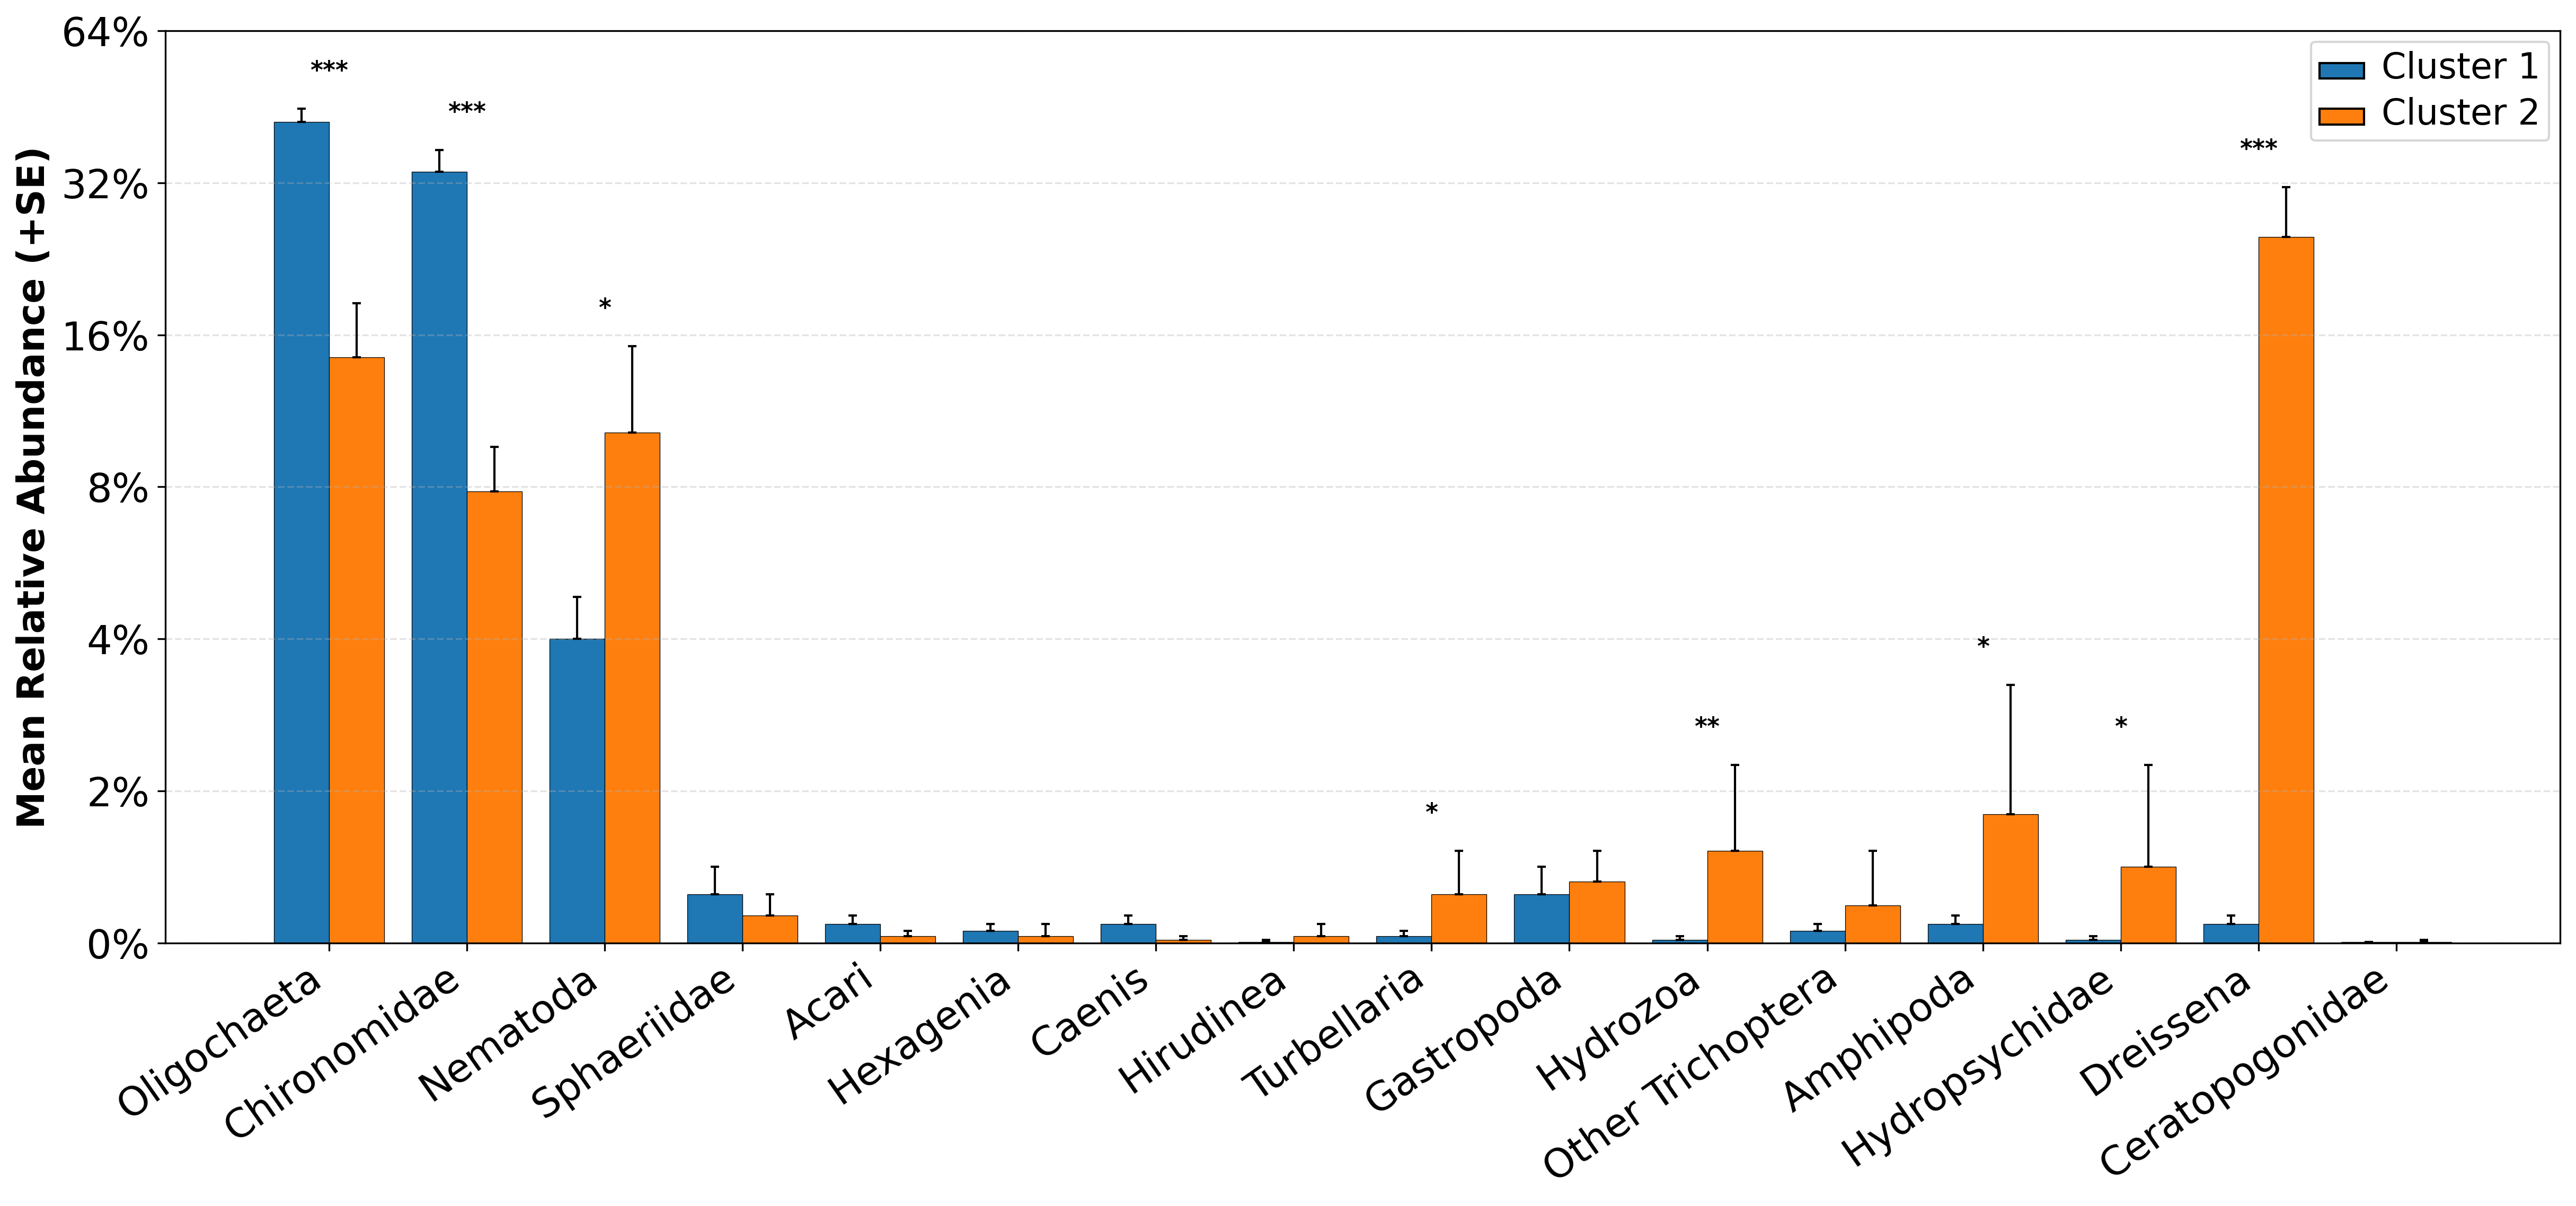

In [42]:
barplot_figure, barplot_axis = render_finalized_cluster_barplot(
    finalized_cluster_anova_table,
    ward_ref,
    FINAL_K,
    )
barplot_axis.set_ylabel("Mean Relative Abundance (+SE)", fontsize=17, fontweight="bold")
barplot_axis.tick_params(axis="x", labelsize=18)
barplot_axis.tick_params(axis="y", labelsize=18)
legend = barplot_axis.get_legend()
if legend is not None:
    for text in legend.get_texts():
        text.set_fontsize(16)
plt.savefig(FIGURE_DIR / "ch3_fw1_finalized_cluster_barplot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(barplot_figure)

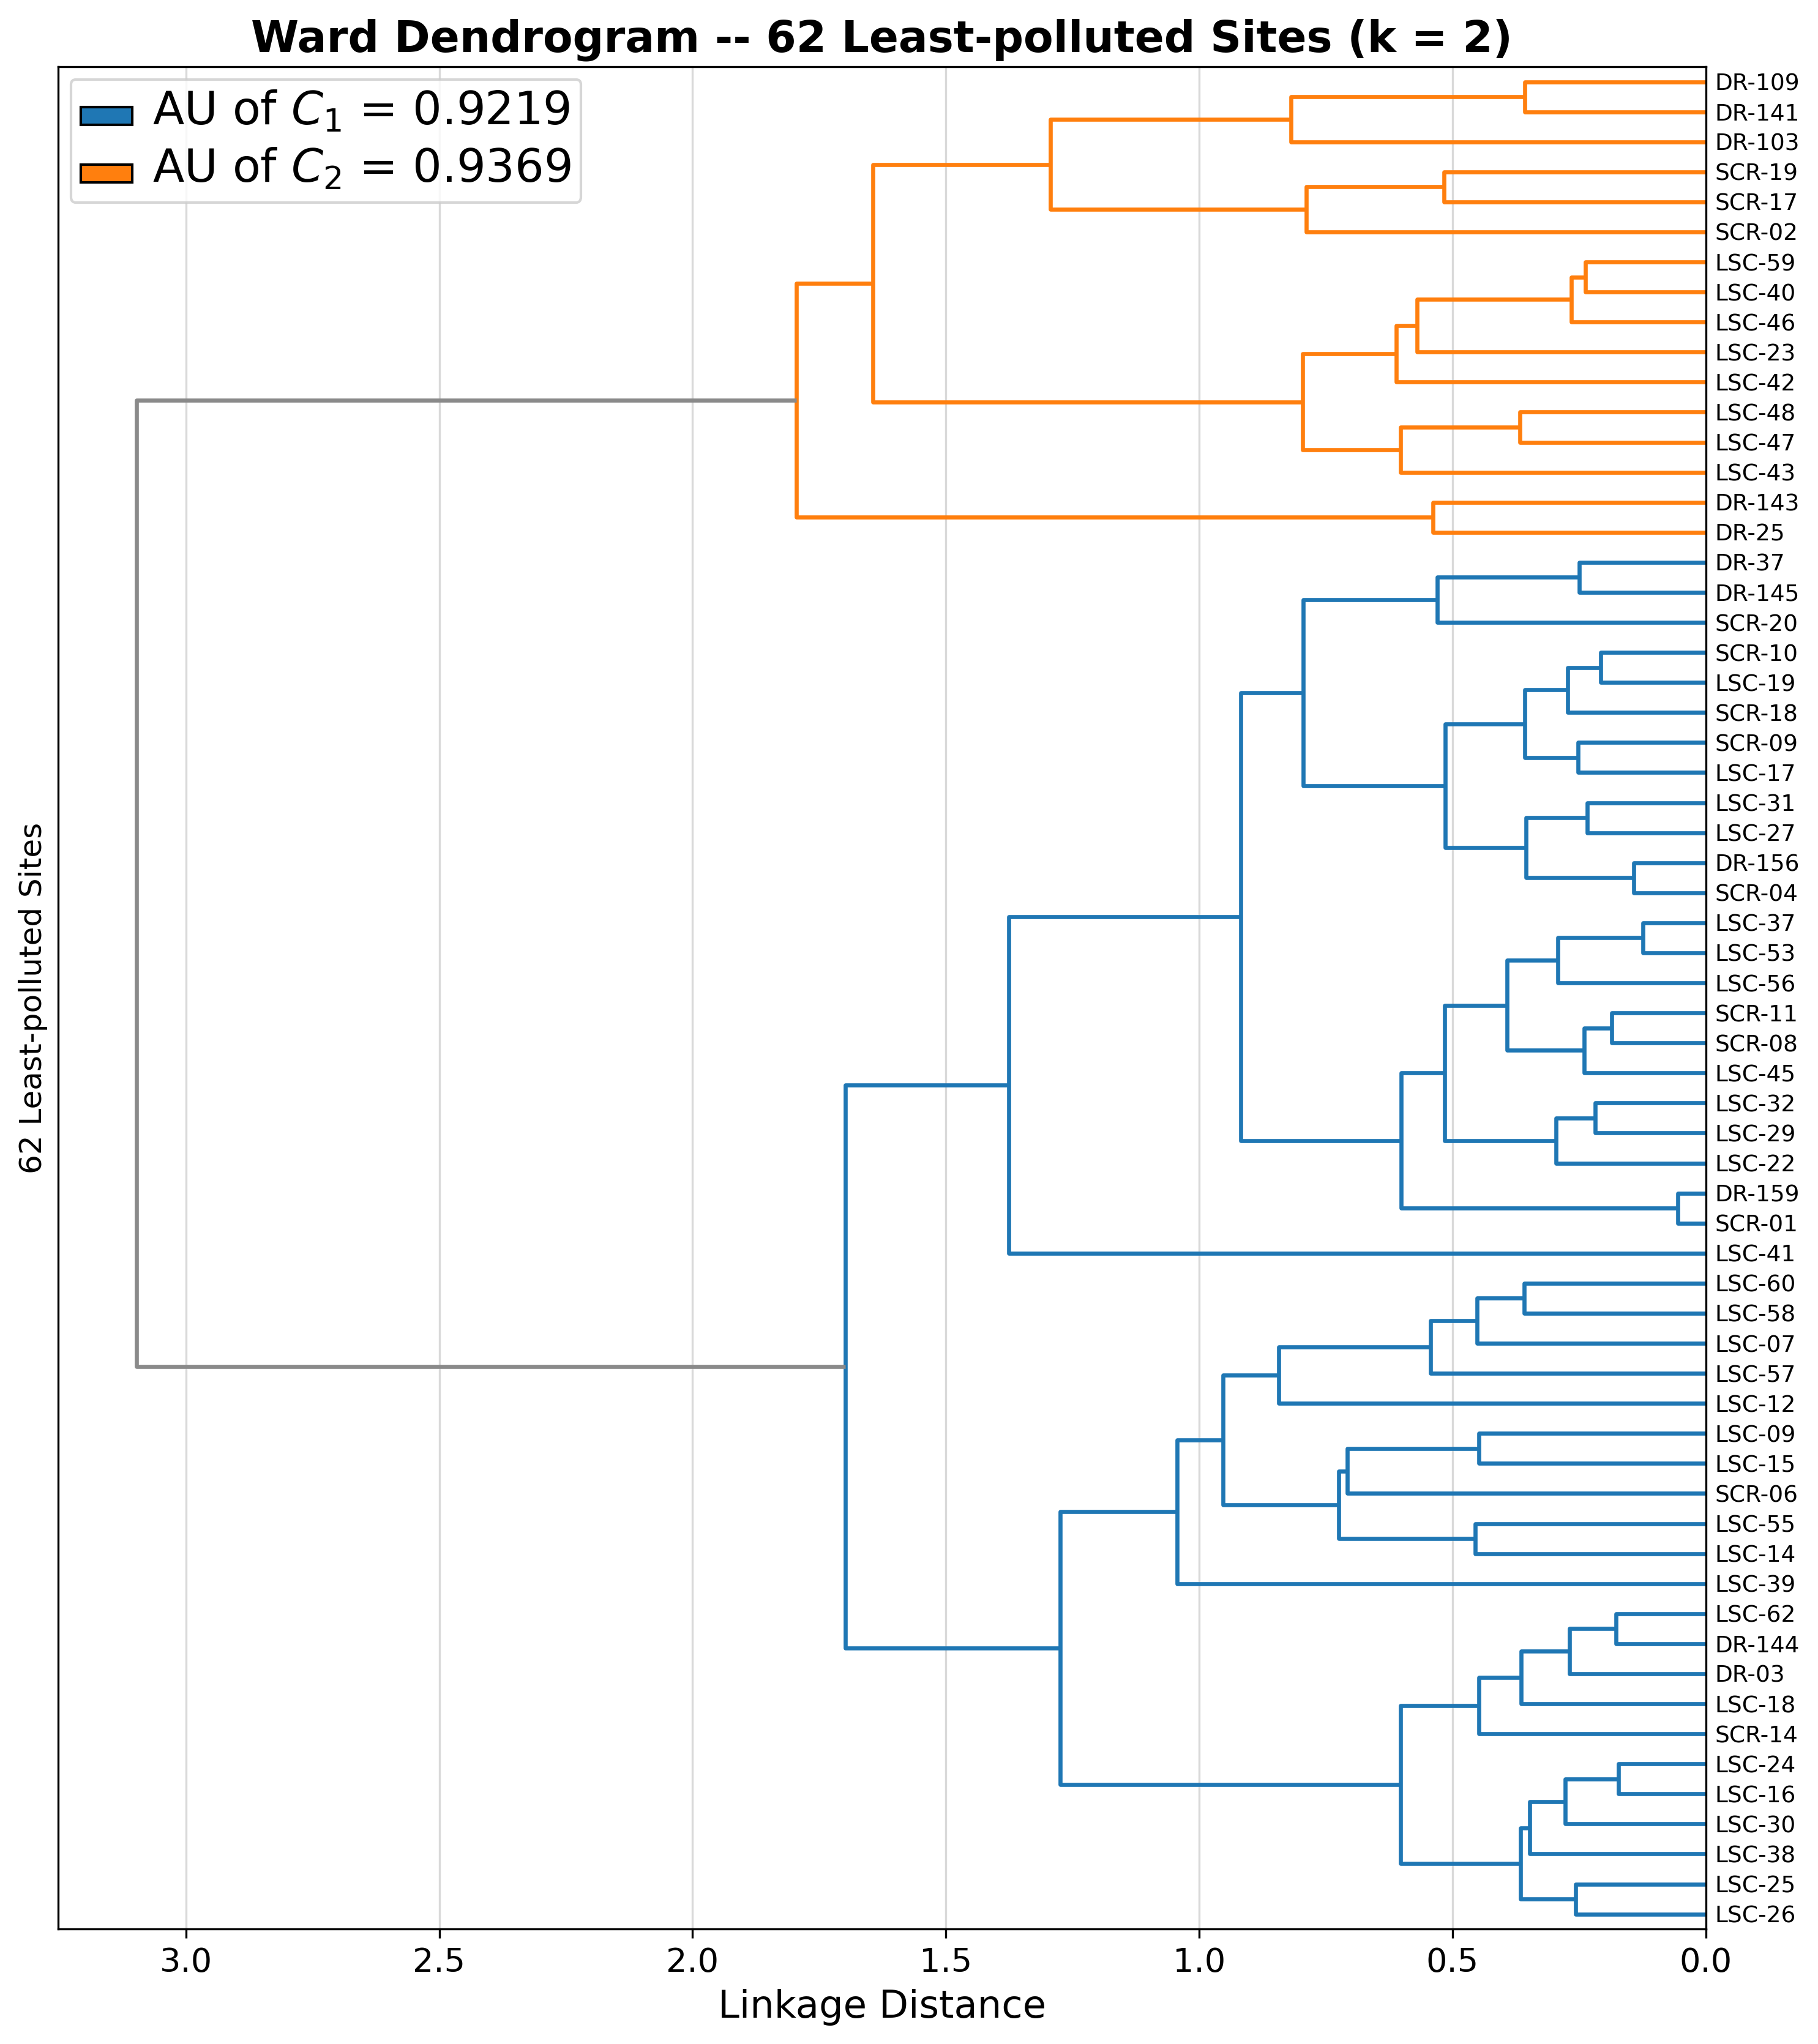

In [43]:
figure, axis = render_cluster_dendrogram(
    ward_ref,
    final_k=FINAL_K,
    pvclust_result=pvclust_result,
    figure_path=None,
    dpi=300,
    )
axis.set_xlabel(axis.get_xlabel(), fontsize=15)
axis.tick_params(axis="x", labelsize=13)
legend = axis.get_legend()
if legend is not None:
    for text in legend.get_texts():
        text.set_fontsize(18)
plt.savefig(FIGURE_DIR / "ch3_fw1_cluster_dendrogram_AUs.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(figure)

# Execution summary

After a complete corridor-case run, this notebook produces:

```text
../results/ch3_fw1_nodewise_anova_table.xlsx
../results/ch3_fw1_finalized_cluster_anova_table.xlsx
../results/ch3_fw1_pvclust_cluster_results.xlsx
../artifacts/A3_final_cluster_labels.xlsx
../figures/ch3_fw1_finalized_cluster_barplot.png
../figures/ch3_fw1_cluster_dendrogram_AUs.png
```

When `STUDY_CASE = "DR"`, the same output filenames are written under:

```text
../DetroitRiverCase/results/
../DetroitRiverCase/artifacts/
../DetroitRiverCase/figures/
```